- **학습 목표**: 임의로 정하던 `n_components`를 데이터 기반으로 결정하는 방법을 익힌다.
- **핵심 개념**: 누적 설명 분산(cumulative explained variance)이 목표 임계값(예: 90%)을 넘는 최소 주성분 개수를 고르는 것이 표준적인 방법입니다. Scree plot은 고유값이 급격히 꺾이는 지점(elbow)을 눈으로 찾는 보조 도구입니다.
- **구현 과제 (스스로 작성)**:

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

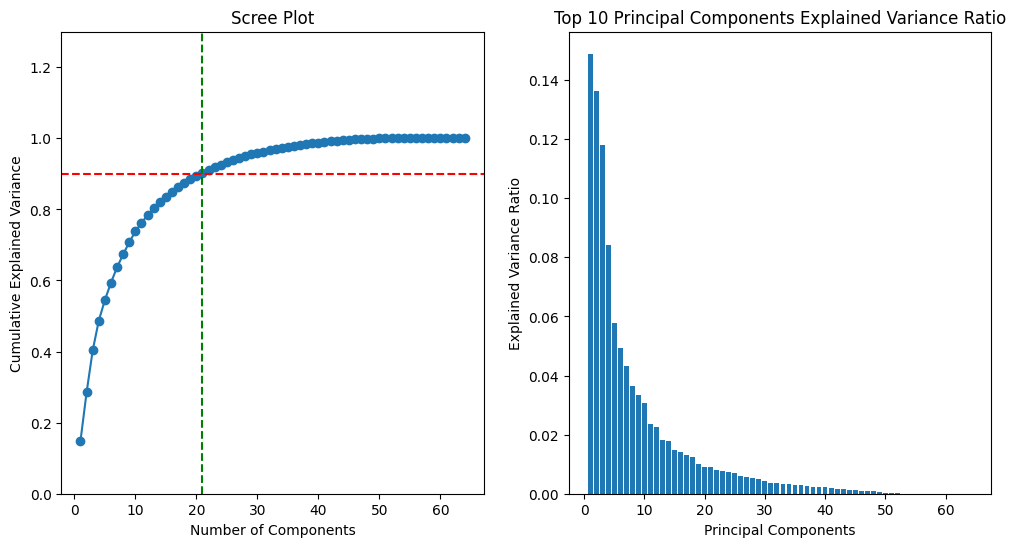

In [22]:
from scipy.sparse import find
def find_k_for_variance(X_scaled: np.ndarray, threshold: float = 0.90) -> int:
  """
  요구사항:
  - n_components를 지정하지 않은 PCA()를 fit해 전체 성분을 계산한다.
  - explained_variance_ratio_의 누적합을 구한다.
  - 누적합이 threshold 이상이 되는 최소 k를 반환한다.
  """
  pca = PCA()
  result = pca.fit_transform(X_scaled)
  explained_variance_ratio = pca.explained_variance_ratio_
  cumsum = np.cumsum(explained_variance_ratio)
  return np.where(cumsum >= threshold)[0][0] + 1
def plot_variance_analysis(X_scaled, k, threshold: float = 0.90):
  """
  요구사항:
  - 왼쪽 subplot: 누적 설명 분산 곡선 + threshold 수평선 + k 수직선.
  - 오른쪽 subplot: 상위 10개 주성분의 설명 분산 비율 막대그래프 (scree plot).
  - save_path로 저장.
  """
  pca = PCA()
  result = pca.fit_transform(X_scaled)
  explained_variance_ratio = pca.explained_variance_ratio_
  cumsum = np.cumsum(explained_variance_ratio)
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
  ax1.plot(range(1, len(cumsum) + 1), cumsum, marker='o', linestyle='-')
  ax1.axhline(y=threshold, color='r', linestyle='--')
  ax1.axvline(x=k, color='g', linestyle='--')
  ax1.set_ylim(0,1.3)
  ax1.set_xlabel('Number of Components')
  ax1.set_ylabel('Cumulative Explained Variance')
  ax1.set_title('Scree Plot')
  ax2.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
  ax2.set_xlabel('Principal Components')
  ax2.set_ylabel('Explained Variance Ratio')
  ax2.set_title('Top 10 Principal Components Explained Variance Ratio')
  plt.show()

data = load_digits()
X, y = data.data, data.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
k = find_k_for_variance(X)
plot_variance_analysis(X, k=k)

  - W1에서 쓴 2차원은 digits 분산의 몇 %만 설명하는가? 그렇다면 W1의 시각화는 "정보 보존"이 아니라 무엇을 위한 것이었는가?
  - Scree plot에서 elbow가 뚜렷하지 않다면 어떻게 판단해야 하는가?

W1에서 쓴 2차원은 분산의 약 20프로 정도만 설명한다. 64차원에서의 거리^2 = 2차원에서의 거리^2 + 버려진 62차원에서의 거리^2, 버려진 차원의 거리^2은 항상 0보다 크다. 따라서, 2차원에서의 거리^2 <= 62차원에서의 거리^2
-> 분리된 그룹에 대해서는 최소 거리가 보장되고, 겹쳐진 그룹에서는 최대 거리가 보장되지 못한다. 이 비대칭성 때문에 2D 시각화는 분리되어 보이는 패턴에 대한 증거를 보여주는 도구이다.

elbow가 뚜렷하지 않은 경우 threshold를 기준으로 판단한다.
